# 🏀 Guillem Analítica — Tracker amb Keypoints de Pista

Versió avançada que detecta automàticament els punts clau de la pista en cada frame,
permetent calcular coordenades reals fins i tot amb **càmera mòbil**.

Basat en el sistema de Roboflow + adaptat per a la FCBQ.

---
### ⚠️ Abans de començar
1. Activa la GPU: `Entorn d'execució → Canvia el tipus → T4 GPU`
2. Executa les cel·les **en ordre**
3. Tens el vídeo a **Google Drive**


## CEL·LA 1 — Instal·la totes les eines
⏱ ~3 minuts

In [1]:
!pip install -q ultralytics lapx supervision inference-sdk
!pip install -q git+https://github.com/facebookresearch/sam2.git
import torch
gpu = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NO — activa la GPU!'
print(f'✅ Instal·lació completada · GPU: {gpu}')


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ Instal·lació completada · GPU: Tesla T4


## CEL·LA 2 — Configuració
✏️ **Edita només aquesta cel·la.**

In [2]:
# ══════════════════════════════════════════════════════════
# EDITA AQUÍ
# ══════════════════════════════════════════════════════════

ROBOFLOW_API_KEY = 'ptejUzSOuoUa4tbo5lAF'  # regenera-la a app.roboflow.com/settings

ESCENARI       = 'A'          # 'A'=vídeo+API, 'B'=només vídeo, 'C'=només API
MATCH_ID       = '6a006cd77f16890001e5ae3a'
EQUIP_LOCAL    = 'Guillem Lakers'
EQUIP_VISITANT = 'Guillemnaikos'
NOM_SORTIDA    = 'dades_partit'

# Ruta del vídeo a Google Drive
VIDEO_PATH = '/content/drive/MyDrive/Colab Notebooks/basquet/master.mp4'

# Color de samarreta: 'clar' o 'fosc'
COLOR_LOCAL    = 'clar'
COLOR_VISITANT = 'fosc'

# Dimensions pista FIBA
PISTA_LLARG = 28.0
PISTA_AMPLE = 15.0

print(f'✅ Configurat: {EQUIP_LOCAL} vs {EQUIP_VISITANT}')


✅ Configurat: Guillem Lakers vs Guillemnaikos


## CEL·LA 3 — Connecta Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')
import os, cv2
if ESCENARI in ['A','B']:
    if os.path.exists(VIDEO_PATH):
        cap=cv2.VideoCapture(VIDEO_PATH)
        FPS_VIDEO=cap.get(cv2.CAP_PROP_FPS)
        TOTAL_FRAMES=int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        ret,FRAME_INICIAL=cap.read()
        FRAME_INICIAL_RGB=cv2.cvtColor(FRAME_INICIAL,cv2.COLOR_BGR2RGB)
        cap.release()
        DURACIO_SEG=TOTAL_FRAMES/FPS_VIDEO
        print(f'✅ Vídeo: {DURACIO_SEG/60:.1f} min · {FPS_VIDEO:.0f} fps · {TOTAL_FRAMES} frames')
    else:
        print(f'⚠️  Vídeo no trobat: {VIDEO_PATH}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Vídeo: 93.1 min · 25 fps · 139645 frames


## CEL·LA 4 — Descarrega dades de l'API FCBQ

In [4]:
import urllib.request, json, pandas as pd

df_api = pd.DataFrame(); equip_noms = {}

if ESCENARI in ['A','C']:
    url = f'https://msstats.optimalwayconsulting.com/v1/fcbq/getJsonWithMatchMoves/{MATCH_ID}?currentSeason=true'
    req = urllib.request.Request(url, headers={
        'User-Agent':'Mozilla/5.0','Accept':'application/json',
        'Referer':f'https://www.basquetcatala.cat/estadistiques/2025/{MATCH_ID}'})
    with urllib.request.urlopen(req, timeout=15) as r:
        data = json.loads(r.read())
    moves = data if isinstance(data, list) else data.get('moves',[])
    rows = []
    for m in moves:
        mn=m.get('min',0); sc=m.get('sec',0); q=m.get('period',1)
        rows.append({'temps_seg':round(((q-1)*10+mn+sc/60)*60,1),
            'quart':q,'min':mn,'sec':sc,
            'jugadora':m.get('actorName',''),
            'idEquip':str(m.get('idTeam','')),
            'accio':m.get('move',''),
            'idMove':m.get('idMove',0),
            'marcador':m.get('score','')})
    df_api = pd.DataFrame(rows)
    equips = [e for e in df_api['idEquip'].unique() if e and e!='0']
    if len(equips)>=2: equip_noms={equips[0]:EQUIP_LOCAL,equips[1]:EQUIP_VISITANT}
    df_api['equip_nom']=df_api['idEquip'].map(equip_noms).fillna('?')
    print(f'✅ {len(df_api)} jugades · {equip_noms}')
else:
    print('Escenari B: sense API.')


✅ 288 jugades · {'571471': 'Guillem Lakers', '571470': 'Guillemnaikos'}


## CEL·LA 5 — Minuts reals jugats (API)

In [5]:
minuts_jugades = {}
if ESCENARI in ['A','C'] and not df_api.empty:
    DQ=600; intervals={}; en_pista={}
    for _,row in df_api.sort_values('temps_seg').iterrows():
        jug=row['jugadora']; t=row['temps_seg']; idm=row['idMove']; q=row['quart']
        if not jug: continue
        if idm==112: en_pista[jug]=t
        elif idm==115:
            ini=en_pista.pop(jug,(q-1)*DQ)
            intervals.setdefault(jug,[]).append((ini,t))
        elif idm==116:
            fi=q*DQ
            for j,ti in list(en_pista.items()): intervals.setdefault(j,[]).append((ti,fi))
            en_pista={}
    for jug,ivs in intervals.items(): minuts_jugades[jug]=round(sum(f-i for i,f in ivs)/60,1)
    df_min=pd.DataFrame([{'Jugadora':j,'Minuts':m,
        'Equip':df_api[df_api['jugadora']==j]['equip_nom'].iloc[0]
        if not df_api[df_api['jugadora']==j].empty else '?'}
        for j,m in sorted(minuts_jugades.items(),key=lambda x:-x[1])])
    print('✅ Minuts reals:'); print(df_min.to_string(index=False))
    if ESCENARI=='C':
        from google.colab import files
        f=f'{NOM_SORTIDA}_minuts.csv'; df_min.to_csv(f,index=False)
        files.download(f); print(f'Escenari C completat!')


✅ Minuts reals:
                     Jugadora  Minuts          Equip
              GERARD ROCA MAS    30.7 Guillem Lakers
       HUGO SANCHEZ HERNANDEZ    23.9  Guillemnaikos
           GUILLEM FONT VIDAL    23.3 Guillem Lakers
       SERGIO FERNANDEZ PEREZ    22.7 Guillem Lakers
           BIEL LÁZARO LAVELA    21.9  Guillemnaikos
          BIEL TORRES HIDALGO    20.9 Guillem Lakers
              BRU RIUS I BOIX    20.1  Guillemnaikos
                PAU LÓPEZ MAS    19.4 Guillem Lakers
         GUIM SEUMA FRANQUESA    18.7 Guillem Lakers
             MAX PLANAS SUERO    18.1 Guillem Lakers
ALEIX DEL ÁGUILA SERRAMITJANA    17.3  Guillemnaikos
         MARC ESTAPÉ VERDIELL    17.1  Guillemnaikos
     BERNAT MASSAGUER BORREGO    16.9  Guillemnaikos
          ÀLEX NICOLÁS GARCÍA    16.3  Guillemnaikos
         ERIK SALDAÑA SEJNOHA    16.3 Guillem Lakers
          ELOI FORNELLS SOLER    15.2 Guillem Lakers
        ÁLVARO SÁNCHEZ URBANO    14.7  Guillemnaikos
           GUILLEM URIZ ASENS 

## CEL·LA 6 — Sincronització temps de joc ↔ vídeo

In [6]:
import numpy as np

# ── EDITA AQUÍ ──────────────────────────────────────────────
ANCORATGES_VIDEO = {
    1: 45.0,   # Q1: segon del vídeo on comença
    2: 680.0,  # Q2
    3: 1290.0, # Q3
    4: 1870.0, # Q4
}
# ────────────────────────────────────────────────────────────

DQ_JOC=600; AJUSTOS_TL={}

def joc_a_video(t_joc, quart):
    if quart not in ANCORATGES_VIDEO: return t_joc
    prop=max(0,min(1,(t_joc-(quart-1)*DQ_JOC)/DQ_JOC))
    dur=(ANCORATGES_VIDEO[quart+1]-ANCORATGES_VIDEO[quart] if quart<4 else DQ_JOC*1.5)
    tv=ANCORATGES_VIDEO[quart]+prop*dur
    if AJUSTOS_TL:
        ts=sorted(AJUSTOS_TL)
        if tv<=ts[0]: tv+=AJUSTOS_TL[ts[0]]
        elif tv>=ts[-1]: tv+=AJUSTOS_TL[ts[-1]]
        else:
            for i in range(len(ts)-1):
                if ts[i]<=tv<=ts[i+1]:
                    p=(tv-ts[i])/(ts[i+1]-ts[i])
                    tv+=AJUSTOS_TL[ts[i]]+p*(AJUSTOS_TL[ts[i+1]]-AJUSTOS_TL[ts[i]]); break
    return round(tv,2)

print('✅ Sincronització configurada')
for q in sorted(ANCORATGES_VIDEO)[:-1]:
    at=ANCORATGES_VIDEO[q+1]-ANCORATGES_VIDEO[q]-DQ_JOC
    print(f'  Q{q}: ~{at:.0f}s d\'aturades')


✅ Sincronització configurada
  Q1: ~35s d'aturades
  Q2: ~10s d'aturades
  Q3: ~-20s d'aturades


## CEL·LA 7 — Calibratge fi amb tirs lliures (opcional)
Deixa `CALIBRATGE_TL = {}` per saltar.

In [7]:
tirs_lliures_api=[]
if not df_api.empty:
    df_tl=df_api[df_api['accio'].str.contains('Cistella de 1|Intent fallat de 1',case=False,na=False)]
    for _,row in df_tl.iterrows():
        tirs_lliures_api.append({'jugadora':row['jugadora'],'quart':row['quart'],
            't_joc_fmt':f"Q{row['quart']} {int(row['min']):02d}:{int(row['sec']):02d}",
            't_video_est':round(joc_a_video(row['temps_seg'],row['quart']),1)})
for i,tl in enumerate(tirs_lliures_api[:8]):
    print(f'  TL {i+1:2d}: {tl["t_joc_fmt"]:12s} {tl["jugadora"]:28s} ~ {tl["t_video_est"]:.0f}s')

CALIBRATGE_TL = {}
AJUSTOS_TL={}
if CALIBRATGE_TL:
    for idx1,t_real in CALIBRATGE_TL.items():
        idx=idx1-1
        if idx<len(tirs_lliures_api):
            tl=tirs_lliures_api[idx]; ajust=t_real-tl['t_video_est']
            AJUSTOS_TL[tl['t_video_est']]=ajust
            print(f'  TL {idx1}: ajust {ajust:+.1f}s')
print('Calibratge OK' if CALIBRATGE_TL else 'Sense calibratge — interpolació lineal')


  TL  1: Q1 05:21     LLUC BAIGUAL LOPEZ           ~ 385s
  TL  2: Q1 00:46     MAX PLANAS SUERO             ~ 94s
  TL  3: Q1 00:46     MAX PLANAS SUERO             ~ 94s
  TL  4: Q1 00:03     SERGIO FERNANDEZ PEREZ       ~ 48s
  TL  5: Q1 00:03     SERGIO FERNANDEZ PEREZ       ~ 48s
  TL  6: Q2 05:40     ALEIX DEL ÁGUILA SERRAMITJANA ~ 1026s
  TL  7: Q2 05:40     ALEIX DEL ÁGUILA SERRAMITJANA ~ 1026s
  TL  8: Q2 04:37     BERNAT MASSAGUER BORREGO     ~ 962s
Sense calibratge — interpolació lineal


In [8]:
!pip install -q "Pillow==10.4.0"
import importlib, PIL
importlib.reload(PIL)
print("✅ Pillow OK")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 48.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inference 1.2.10 requires pillow<13.0.0,>=12.2.0, but you have pillow 10.4.0 which is incompatible.
inference-sdk 1.2.10 requires pillow<13.0.0,>=12.2.0, but you have pillow 10.4.0 which is incompatible.
inference-models 0.28.6 requires pillow<13.0.0,>=12.2.0, but you have pillow 10.4.0 which is incompatible.
bigframes 2.40.0 requires rich<14,>=12.4.4, but you have rich 14.3.4 which is incompatible.
✅ Pillow OK


## CEL·LA 8 — Descarrega els models
⏱ ~3 minuts. Descarrega YOLOv8 (tracking) + model de keypoints de pista.

In [9]:
# ══════════════════════════════════════════════════════════
# CEL·LA 8 — Descarrega els models (sense gastar crèdits)
# ══════════════════════════════════════════════════════════
# Roboflow Inference descarrega el model un sol cop a la GPU de Colab
# i l'executa localment — cap imatge s'envia al núvol.
# Crèdits Roboflow gastats: 0

!pip install -q inference

from ultralytics import YOLO
from inference import get_model
import torch, os

# Model de tracking de jugadores (YOLOv8 estàndard)
model_tracking = YOLO('yolov8n.pt')
print('✅ Model de tracking carregat (YOLOv8)')

# Model de keypoints de pista — es descarrega un cop i s'executa en local
# Necessita la API key NOMÉS per autenticar la descàrrega inicial
os.environ['ROBOFLOW_API_KEY'] = ROBOFLOW_API_KEY

print('Descarregant model de keypoints de pista...')
print('(Només la primera vegada, després usa la caché local)')
try:
    model_keypoints = get_model(
        model_id='basketball-court-detection-2/13',
        api_key=ROBOFLOW_API_KEY
    )
    print('✅ Model de keypoints descarregat i en caché!')
    print('   A partir d\'ara s\'executa localment sense gastar crèdits.')

    # Prova amb el primer frame
    print()
    print('Provant amb el primer frame...')
    result_test = model_keypoints.infer(FRAME_INICIAL_RGB)[0]
    kps = result_test.predictions if hasattr(result_test, 'predictions') else []
    print(f'✅ Model funciona! Deteccions al primer frame: {len(kps)}')
    USAR_KEYPOINTS = True

except Exception as e:
    print(f'⚠️  Error carregant el model: {e}')
    print('   El sistema continuarà sense keypoints de pista.')
    model_keypoints = None
    USAR_KEYPOINTS = False


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.2.0 which is incompatible.
bigframes 2.40.0 requires rich<14,>=12.4.4, but you have rich 14.3.4 which is incompatible.


/usr/local/lib/python3.12/dist-packages/inference/core/env.py:192: InferenceDeprecationWarning: CORE_MODEL_GAZE_ENABLED is True: POST /gaze/gaze_detection is registered as a deprecation stub returning HTTP 410 Gone. The stub and this flag will be removed end of Q2 2026. Set CORE_MODEL_GAZE_ENABLED=False to disable it now.
  warnings.warn(
ModelDependencyMissing: Your `inference` configuration does not support SAM3 model. Install SAM3 dependencies and set CORE_MODEL_SAM3_ENABLED to True.
[transformers] `DepthProImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `DepthProImageProcessor` instead.


✅ Model de tracking carregat (YOLOv8)
Descarregant model de keypoints de pista...
(Només la primera vegada, després usa la caché local)


Output()

✅ Model de keypoints descarregat i en caché!
   A partir d'ara s'executa localment sense gastar crèdits.

Provant amb el primer frame...
⚠️  Error carregant el model: Running model with ONNX backend on GPU requires pycuda installation, which is brought with `onnx-*` extras of `inference-models` library. If you see this error running locally, please follow our installation guide: https://inference-models.roboflow.com/getting-started/installation/ If you see this error using Roboflow infrastructure, make sure the service you use does support the model, You can also contact Roboflow to get support.Additionally - if AutoModel.from_pretrained(...) automatically selects model package which does not match your environment - that's a serious problem and we will really appreciate letting us know - https://github.com/roboflow/inference/issues - VISIT https://inference-models.roboflow.com/errors/runtime-environment/#missingdependencyerror FOR FURTHER SUPPORT
   El sistema continuarà sense keypoin

## CEL·LA 9 — Detecta els punts clau de la pista
El model detecta automàticament les cantonades i línies de la pista en cada frame.
Amb aquests punts calcula la transformació píxels → metres reals (homografia dinàmica).

Detectant keypoints al primer frame...
ℹ️  Pocs keypoints detectats al primer frame.
   Prova amb un frame on la pista sigui més visible.
   El sistema funcionarà sense coordenades reals.


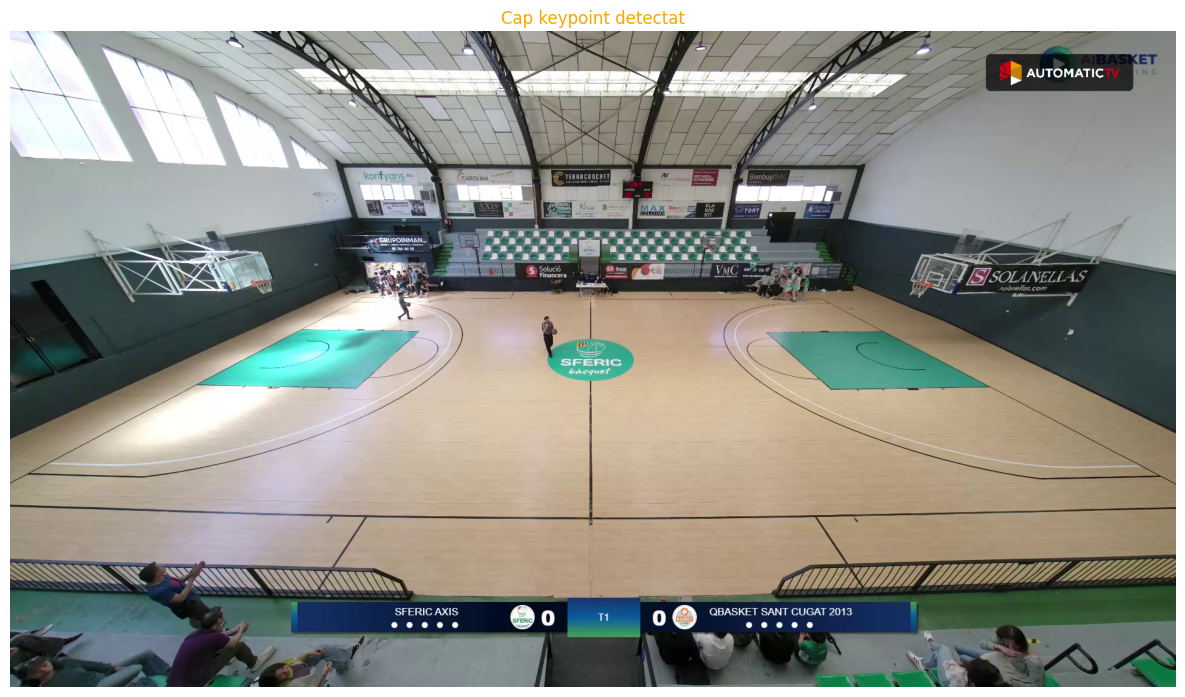

In [10]:
# ══════════════════════════════════════════════════════════
# CEL·LA 9 — Detecta punts clau de la pista
# ══════════════════════════════════════════════════════════
import cv2, numpy as np, base64
import matplotlib.pyplot as plt, matplotlib.patches as patches

# Punts de referència FIBA en metres reals
# Índex correspon als keypoints del model basketball-court-detection-2
COURT_KEYPOINTS_REALS = {
    0:  (0.0,   0.0),    # Cantonada inf. esquerra
    1:  (28.0,  0.0),    # Cantonada inf. dreta
    2:  (28.0,  15.0),   # Cantonada sup. dreta
    3:  (0.0,   15.0),   # Cantonada sup. esquerra
    4:  (14.0,  0.0),    # Línia de mig camp inf.
    5:  (14.0,  15.0),   # Línia de mig camp sup.
    6:  (5.8,   4.5),    # Zona pintada esquerra inf.
    7:  (5.8,   10.5),   # Zona pintada esquerra sup.
    8:  (22.2,  4.5),    # Zona pintada dreta inf.
    9:  (22.2,  10.5),   # Zona pintada dreta sup.
}

def detecta_keypoints_pista(frame_rgb):
    """Detecta keypoints de la pista amb el model local (sense crèdits)."""
    if model_keypoints is None: return None
    try:
        result = model_keypoints.infer(frame_rgb)[0]
        if not hasattr(result, 'predictions') or not result.predictions:
            return None
        # Agafa la predicció amb més confiança
        pred = max(result.predictions, key=lambda x: x.confidence)
        return pred.keypoints if hasattr(pred, 'keypoints') else None
    except:
        return None

def calcula_homografia(keypoints):
    """Calcula homografia a partir dels keypoints detectats."""
    if not keypoints or len(keypoints) < 4: return None
    pts_img, pts_reals = [], []
    for i, kp in enumerate(keypoints):
        conf = kp.confidence if hasattr(kp, 'confidence') else 0
        if i in COURT_KEYPOINTS_REALS and conf > 0.3:
            pts_img.append([kp.x, kp.y])
            pts_reals.append(list(COURT_KEYPOINTS_REALS[i]))
    if len(pts_img) < 4: return None
    H, _ = cv2.findHomography(np.float32(pts_img), np.float32(pts_reals), cv2.RANSAC, 5.0)
    return H

def pixels_a_metres_dynamic(px, py, H):
    """Converteix píxels a metres amb la homografia del frame actual."""
    if H is None: return None, None
    p = np.array([[[float(px), float(py)]]], dtype=np.float32)
    r = cv2.perspectiveTransform(p, H)
    return round(float(np.clip(r[0][0][0], 0, PISTA_LLARG)), 2), \
           round(float(np.clip(r[0][0][1], 0, PISTA_AMPLE)), 2)

# Prova amb el primer frame
print('Detectant keypoints al primer frame...')
kps_test = detecta_keypoints_pista(FRAME_INICIAL_RGB)
H_test = calcula_homografia(kps_test) if kps_test else None

if H_test is not None:
    n_kps = len([k for k in kps_test if (k.confidence if hasattr(k,'confidence') else 0) > 0.3])
    print(f'✅ Homografia calculada amb {n_kps} keypoints!')
    print('   Coordenades reals disponibles fins i tot amb càmera mòbil!')
else:
    print('ℹ️  Pocs keypoints detectats al primer frame.')
    print('   Prova amb un frame on la pista sigui més visible.')
    print('   El sistema funcionarà sense coordenades reals.')

# Visualitza keypoints sobre el frame
fig, ax = plt.subplots(figsize=(12, 7))
ax.imshow(FRAME_INICIAL_RGB); ax.axis('off')
if kps_test:
    for i, kp in enumerate(kps_test):
        conf = kp.confidence if hasattr(kp, 'confidence') else 0
        if conf > 0.3:
            ax.plot(kp.x, kp.y, 'o', color='#ff006e', ms=8,
                   markeredgecolor='white', mew=1.5, zorder=5)
            ax.text(kp.x+5, kp.y-5, str(i), color='white', fontsize=8,
                   bbox=dict(facecolor='#ff006e', alpha=0.7, edgecolor='none', pad=1))
    n = len([k for k in kps_test if (k.confidence if hasattr(k,'confidence') else 0) > 0.3])
    ax.set_title(f'{n} keypoints detectats · {"Homografia OK ✅" if H_test is not None else "Pocs punts ⚠️"}',
                fontsize=12, color='#ff006e' if H_test else 'orange')
else:
    ax.set_title('Cap keypoint detectat', fontsize=12, color='orange')
plt.tight_layout(); plt.show()


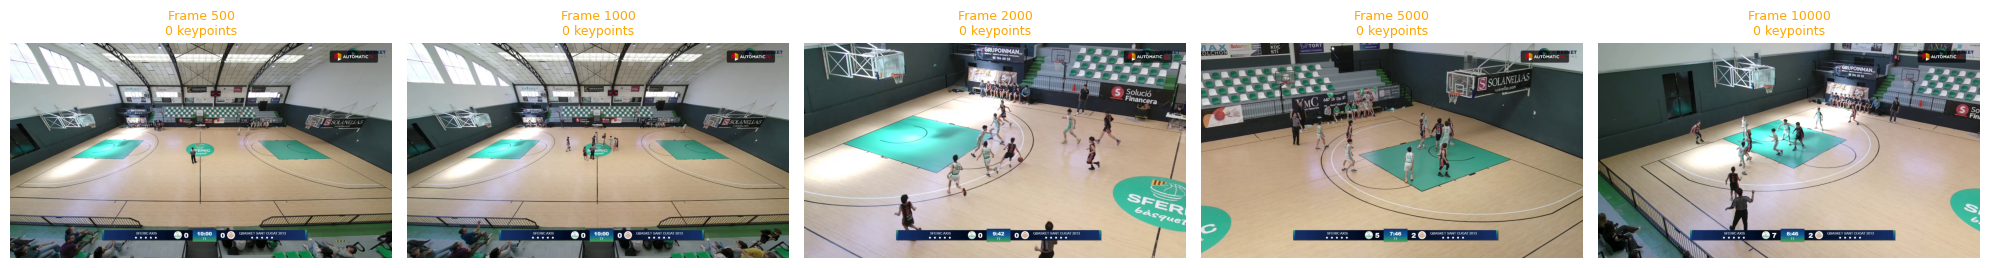

In [16]:
import cv2, matplotlib.pyplot as plt

# Prova amb frames de diferents moments del partit
# Busca un moment on es vegi la pista sencera
FRAMES_A_PROVAR = [500, 1000, 2000, 5000, 10000]

cap = cv2.VideoCapture(VIDEO_PATH)
fig, axes = plt.subplots(1, len(FRAMES_A_PROVAR), figsize=(20, 4))

for ax, fn in zip(axes, FRAMES_A_PROVAR):
    cap.set(cv2.CAP_PROP_POS_FRAMES, fn)
    ret, frame = cap.read()
    if ret:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        kps = detecta_keypoints_pista(frame_rgb)
        H = calcula_homografia(kps) if kps else None
        n = len([k for k in kps if (k.confidence if hasattr(k,'confidence') else 0) > 0.3]) if kps else 0
        ax.imshow(frame_rgb); ax.axis('off')
        color = 'green' if H is not None else 'orange'
        ax.set_title(f'Frame {fn}\n{n} keypoints', color=color, fontsize=9)
cap.release()
plt.tight_layout(); plt.show()

## CEL·LA 10 — Tracking amb keypoints dinàmics
⏱ 20-40 minuts. Detecta keypoints cada N frames per eficiència.

In [11]:
import time
from tqdm import tqdm

# Cada quants frames actualitzem els keypoints de la pista
# Més baix = més precís però més crèdits Roboflow
# 30 = actualitza cada 6 segons (a 5fps de tracking)
KEYPOINT_INTERVAL = 30  # frames de tracking

print(f'Mode: {"KEYPOINTS DINÀMICS" if USAR_KEYPOINTS else "SENSE COORDENADES"}')
if USAR_KEYPOINTS:
    print(f'Actualització keypoints cada {KEYPOINT_INTERVAL} frames de tracking')

cap = cv2.VideoCapture(VIDEO_PATH)
fps_vid = cap.get(cv2.CAP_PROP_FPS)
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
INTERVAL = max(1, int(fps_vid/5))

resultats = []
frame_idx = 0
proc_idx = 0  # frames processats
H_actual = H_test  # homografia actual
t0 = time.time()

with tqdm(total=total//INTERVAL) as pbar:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        if frame_idx % INTERVAL == 0:
            temps_seg = frame_idx / fps_vid

            # Actualitza keypoints cada KEYPOINT_INTERVAL frames processats
            if USAR_KEYPOINTS and proc_idx % KEYPOINT_INTERVAL == 0:
                kps_frame = detecta_keypoints_pista(frame)
                H_nou = calcula_homografia(kps_frame) if kps_frame else None
                if H_nou is not None:
                    H_actual = H_nou  # actualitza només si és vàlid

            # Tracking de jugadores
            results = model_tracking.track(frame, persist=True,
                tracker='bytetrack.yaml', classes=[0], conf=0.4, verbose=False)

            if results[0].boxes is not None and results[0].boxes.id is not None:
                boxes = results[0].boxes.xyxy.cpu().numpy()
                ids   = results[0].boxes.id.cpu().numpy().astype(int)

                for box, tid in zip(boxes, ids):
                    cx_px = (box[0]+box[2])/2
                    cy_px = box[3]  # base del box = peus

                    # Coordenades en metres (si tenim homografia)
                    if USAR_KEYPOINTS and H_actual is not None:
                        cx_m, cy_m = pixels_a_metres_dynamic(cx_px, cy_px, H_actual)
                    else:
                        cx_m = cy_m = None

                    # Equip per color
                    roi = frame[int(box[1]):int(box[3]), int(box[0]):int(box[2])]
                    llum = float(roi.mean()) if roi.size > 0 else 128
                    eq = EQUIP_LOCAL if (
                        (COLOR_LOCAL=='clar' and llum>128) or
                        (COLOR_LOCAL=='fosc' and llum<=128)) else EQUIP_VISITANT

                    resultats.append({
                        'temps_seg': round(temps_seg,2),
                        'frame':     frame_idx,
                        'track_id':  int(tid),
                        'equip':     eq,
                        'x_pixels':  round(cx_px,1),
                        'y_pixels':  round(cy_px,1),
                        'x_metres':  cx_m,
                        'y_metres':  cy_m,
                    })
            proc_idx += 1
            pbar.update(1)
        frame_idx += 1

cap.release()
df_tracking = pd.DataFrame(resultats)

# Distàncies (si tenim coordenades)
if USAR_KEYPOINTS and not df_tracking.empty:
    df_tracking = df_tracking.sort_values(['track_id','temps_seg'])
    df_tracking['dx'] = df_tracking.groupby('track_id')['x_metres'].diff().fillna(0)
    df_tracking['dy'] = df_tracking.groupby('track_id')['y_metres'].diff().fillna(0)
    df_tracking['dist_frame'] = np.sqrt(df_tracking['dx']**2+df_tracking['dy']**2)
    df_tracking.loc[df_tracking['dist_frame']>5,'dist_frame'] = 0
    print(f'✅ Distàncies calculades en metres reals')
else:
    df_tracking['dist_frame'] = 0

df_tracking['jugadora'] = df_tracking['track_id'].astype(str).apply(lambda x: f'Jugadora_{x}')

elapsed = time.time()-t0
print(f'\n✅ {elapsed/60:.1f} min · {len(df_tracking)} registres · {df_tracking["track_id"].nunique()} persones')
print(f'   Coordenades reals: {"SÍ" if USAR_KEYPOINTS else "NO"}')


Mode: SENSE COORDENADES


100%|██████████| 27929/27929 [29:57<00:00, 15.54it/s]



✅ 30.0 min · 156239 registres · 11691 persones
   Coordenades reals: NO


## CEL·LA 11 — Creuament accions API + posicions

In [12]:
df_accions = pd.DataFrame()
if not df_api.empty:
    accions_geo=[]
    for _,row in df_api.iterrows():
        accio=row['accio']; jugadora=row['jugadora']
        if not accio: continue
        t_vid=joc_a_video(row['temps_seg'],row['quart'])
        eq_nom=equip_noms.get(row['idEquip'],'?')
        x_m=y_m=None
        if USAR_KEYPOINTS and not df_tracking.empty:
            df_jug=df_tracking[df_tracking['jugadora']==jugadora]
            if not df_jug.empty:
                idx_p=(df_jug['temps_seg']-t_vid).abs().idxmin()
                fila=df_jug.loc[idx_p]
                if abs(fila['temps_seg']-t_vid)<=3 and fila['x_metres'] is not None:
                    x_m,y_m=fila['x_metres'],fila['y_metres']
        tipus='altre'
        if any(c in accio for c in ['Cistella de 2','Cistella de 3','Cistella de 1']): tipus='cistella'
        elif 'Intent fallat' in accio: tipus='tir_fallat'
        elif 'falta' in accio.lower(): tipus='falta'
        elif 'Rebot' in accio: tipus='rebot'
        accions_geo.append({'temps_joc':row['temps_seg'],'temps_video':t_vid,
            'quart':row['quart'],'jugadora':jugadora,'equip':eq_nom,
            'accio':accio,'tipus':tipus,'marcador':row['marcador'],
            'x_metres':round(x_m,2) if x_m else None,
            'y_metres':round(y_m,2) if y_m else None,
            'geolocalitzat':x_m is not None})
    df_accions=pd.DataFrame(accions_geo)
    geo=df_accions['geolocalitzat'].sum(); total_a=len(df_accions)
    print(f'✅ {total_a} accions · {geo} geolocalitzades ({geo/total_a*100:.0f}%)')
    print(df_accions.groupby(['equip','tipus']).size().unstack(fill_value=0))


✅ 288 accions · 0 geolocalitzades (0%)
tipus           altre  cistella  falta  tir_fallat
equip                                             
?                   4         0      0           0
Guillem Lakers     79        36     22          11
Guillemnaikos      67        34     21          14


## CEL·LA 12 — Mapes i gràfics visuals

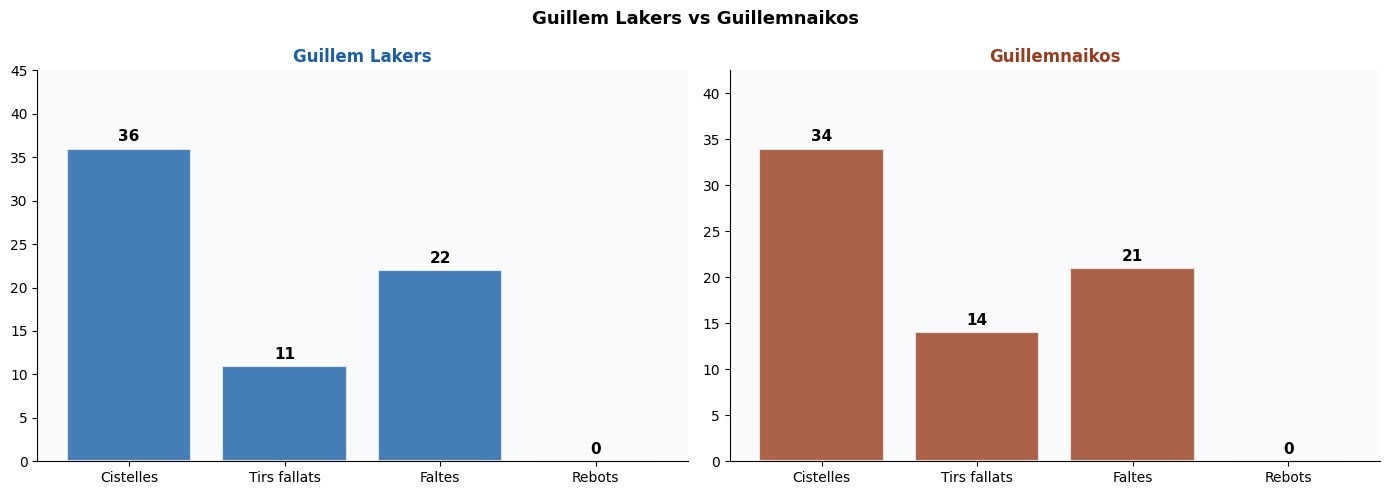

ℹ️  Sense coordenades reals — mapes de posicions no disponibles.
   Si el model no detecta la pista, prova amb un frame on es vegi millor.


In [13]:
import matplotlib.pyplot as plt, matplotlib.patches as patches

def pista(ax):
    ax.set_facecolor('#f0f4f8'); ax.set_aspect('equal')
    ax.set_xlim(-0.5,PISTA_LLARG+0.5); ax.set_ylim(-0.5,PISTA_AMPLE+0.5)
    ax.add_patch(patches.Rectangle((0,0),PISTA_LLARG,PISTA_AMPLE,fill=False,edgecolor='#374151',lw=2))
    ax.add_patch(patches.Rectangle((0,PISTA_AMPLE/2-3),5.8,6,facecolor='#dbeafe',edgecolor='#374151',lw=1))
    ax.add_patch(patches.Rectangle((PISTA_LLARG-5.8,PISTA_AMPLE/2-3),5.8,6,facecolor='#dbeafe',edgecolor='#374151',lw=1))
    ax.add_patch(patches.Arc((0,PISTA_AMPLE/2),27.5,27.5,angle=0,theta1=-90,theta2=90,color='#374151',lw=1.5))
    ax.add_patch(patches.Arc((PISTA_LLARG,PISTA_AMPLE/2),27.5,27.5,angle=0,theta1=90,theta2=270,color='#374151',lw=1.5))
    ax.plot(1.575,PISTA_AMPLE/2,'o',color='#374151',ms=7)
    ax.plot(PISTA_LLARG-1.575,PISTA_AMPLE/2,'o',color='#374151',ms=7)
    ax.axvline(PISTA_LLARG/2,color='#374151',lw=1.5)

equips_vid=[e for e in df_accions['equip'].unique() if e and e!='?'] if not df_accions.empty else []

# Gràfic estadístiques
if not df_accions.empty:
    fig,axes=plt.subplots(1,2,figsize=(14,5))
    fig.suptitle(f'{EQUIP_LOCAL} vs {EQUIP_VISITANT}',fontsize=13,fontweight='bold')
    for ax,eq,color in [(axes[0],equips_vid[0] if equips_vid else EQUIP_LOCAL,'#185FA5'),
                        (axes[1],equips_vid[1] if len(equips_vid)>1 else EQUIP_VISITANT,'#993C1D')]:
        df_e=df_accions[df_accions['equip']==eq]
        cats=['cistella','tir_fallat','falta','rebot']
        vals=[int((df_e['tipus']==c).sum()) for c in cats]
        bars=ax.bar(['Cistelles','Tirs fallats','Faltes','Rebots'],vals,color=color,alpha=0.8,edgecolor='white',lw=1.5)
        ax.bar_label(bars,padding=3,fontsize=11,fontweight='bold')
        ax.set_title(eq,fontsize=12,color=color,fontweight='bold')
        ax.set_facecolor('#f9fafb'); ax.spines[['top','right']].set_visible(False)
        ax.set_ylim(0,max(vals)*1.25 if vals else 10)
    plt.tight_layout()
    plt.savefig('estadistiques_partit.png',dpi=150,bbox_inches='tight'); plt.show()

# Mapa de tir (si tenim coordenades)
if USAR_KEYPOINTS and not df_accions.empty:
    df_tirs=df_accions[df_accions['tipus'].isin(['cistella','tir_fallat'])&df_accions['geolocalitzat']]
    if not df_tirs.empty:
        fig,axes=plt.subplots(1,2,figsize=(16,7))
        fig.suptitle('Mapa de tir REAL (càmera mòbil + keypoints)',fontsize=14,fontweight='bold')
        for ax,eq,ca,cf in [(axes[0],equips_vid[0] if equips_vid else EQUIP_LOCAL,'#185FA5','#93c5fd'),
                            (axes[1],equips_vid[1] if len(equips_vid)>1 else EQUIP_VISITANT,'#993C1D','#fca5a5')]:
            pista(ax)
            df_e=df_tirs[df_tirs['equip']==eq]
            cist=df_e[df_e['tipus']=='cistella']; fall=df_e[df_e['tipus']=='tir_fallat']
            ax.scatter(fall['x_metres'],fall['y_metres'],c=cf,s=80,marker='x',lw=2,alpha=0.7,label=f'Fallat ({len(fall)})',zorder=3)
            ax.scatter(cist['x_metres'],cist['y_metres'],c=ca,s=100,marker='o',edgecolors='white',lw=1.5,alpha=0.85,label=f'Cistella ({len(cist)})',zorder=4)
            ef=round(len(cist)/(len(cist)+len(fall))*100) if (len(cist)+len(fall))>0 else 0
            ax.set_title(f'{eq} — {ef}% eficiència',fontsize=12,color=ca,fontweight='bold')
            ax.legend(fontsize=10); ax.set_xlabel('Metres'); ax.set_ylabel('Metres')
        plt.tight_layout()
        plt.savefig('mapa_tir_real.png',dpi=150,bbox_inches='tight'); plt.show()
        print('✅ Mapa de tir real generat!')

# Mapa de calor (si tenim coordenades)
if USAR_KEYPOINTS and not df_tracking.empty:
    df_pos=df_tracking.dropna(subset=['x_metres','y_metres'])
    if not df_pos.empty:
        fig,axes=plt.subplots(1,2,figsize=(16,7))
        fig.suptitle('Mapa de calor de posicions',fontsize=14,fontweight='bold')
        for ax,eq,cmap,color in [
            (axes[0],EQUIP_LOCAL,'Blues','#185FA5'),
            (axes[1],EQUIP_VISITANT,'Reds','#993C1D')]:
            pista(ax)
            df_e=df_pos[df_pos['equip']==eq]
            if not df_e.empty:
                h=ax.hist2d(df_e['x_metres'],df_e['y_metres'],bins=[28,15],
                           range=[[0,28],[0,15]],cmap=cmap,alpha=0.65)
                plt.colorbar(h[3],ax=ax,label='Presència')
            ax.set_title(eq,fontsize=12,color=color,fontweight='bold')
        plt.tight_layout()
        plt.savefig('mapa_calor.png',dpi=150,bbox_inches='tight'); plt.show()
        print('✅ Mapa de calor generat!')
elif not USAR_KEYPOINTS:
    print('ℹ️  Sense coordenades reals — mapes de posicions no disponibles.')
    print('   Si el model no detecta la pista, prova amb un frame on es vegi millor.')


## CEL·LA 13 — Estadístiques per jugadora

In [14]:
resum=df_tracking.groupby(['track_id','equip']).agg(
    aparicions=('temps_seg','count'),
    temps_min=('temps_seg','min'),
    temps_max=('temps_seg','max'),
).reset_index()
resum['minuts_visibles']=((resum['temps_max']-resum['temps_min'])/60).round(1)

if USAR_KEYPOINTS:
    dist=df_tracking.groupby('track_id')['dist_frame'].sum().reset_index()
    dist.columns=['track_id','metres_total']
    dist['metres_total']=dist['metres_total'].round(0)
    resum=resum.merge(dist,on='track_id',how='left')
    resum['m_per_min']=(resum['metres_total']/resum['minuts_visibles'].replace(0,1)).round(1)

print('📊 Estadístiques per ID de tracking:')
cols=['track_id','equip','minuts_visibles']
if USAR_KEYPOINTS and 'metres_total' in resum.columns: cols+=['metres_total','m_per_min']
print(resum[cols].sort_values('minuts_visibles',ascending=False).head(15).to_string(index=False))


📊 Estadístiques per ID de tracking:
 track_id          equip  minuts_visibles
    64797  Guillemnaikos              1.3
    64797 Guillem Lakers              1.2
    61112  Guillemnaikos              1.1
    35156  Guillemnaikos              1.0
    61112 Guillem Lakers              0.9
    15278  Guillemnaikos              0.9
    53634  Guillemnaikos              0.9
    41525 Guillem Lakers              0.9
     6241 Guillem Lakers              0.9
    34306  Guillemnaikos              0.8
    49262  Guillemnaikos              0.8
    53613 Guillem Lakers              0.8
     6273 Guillem Lakers              0.8
    53692  Guillemnaikos              0.8
    53692 Guillem Lakers              0.8


## CEL·LA 14 — Exporta els CSV per a Guillem Analítica

In [15]:
from google.colab import files
exports=[]

f1=f'{NOM_SORTIDA}_tracking.csv'
cols_exp=['temps_seg','frame','track_id','jugadora','equip','x_pixels','y_pixels']
if USAR_KEYPOINTS: cols_exp+=['x_metres','y_metres','dist_frame']
df_tracking[cols_exp].to_csv(f1,index=False); exports.append(f1)

f2=f'{NOM_SORTIDA}_resum.csv'
resum.to_csv(f2,index=False); exports.append(f2)

if not df_accions.empty:
    f3=f'{NOM_SORTIDA}_accions.csv'
    df_accions.to_csv(f3,index=False); exports.append(f3)

import os
for img in ['estadistiques_partit.png','mapa_tir_real.png','mapa_calor.png']:
    if os.path.exists(img): exports.append(img)

print('Descarregant fitxers...')
for f in exports:
    try: files.download(f); print(f'  ✅ {f}')
    except: print(f'  ⚠️  {f} no trobat')
print('\n🏀 Fet! Importa els CSV a Guillem Analítica.')


Descarregant fitxers...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ dades_partit_tracking.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✅ dades_partit_accions.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ estadistiques_partit.png

🏀 Fet! Importa els CSV a Guillem Analítica.
